In [7]:
import os
print(os.listdir())



['.config', 'test (1) (1).csv', 'train (1).csv', 'data_description (1).txt', 'test (1).csv', 'data_description.txt', 'train (1) (1).csv', 'sample_data']


In [8]:
import pandas as pd

# Carregar usando os nomes exatos que aparecem na lista
train = pd.read_csv("train (1).csv")
test = pd.read_csv("test (1).csv")

print("Treino:")
print(train.head())

print("\nDimensões do treino:", train.shape)
print("Colunas do treino:", train.columns.tolist()[:10])


Treino:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008     

In [9]:
# Ver informações gerais sobre o dataset
print(train.info())

# Estatísticas descritivas das colunas numéricas
print(train.describe())

# Conferir valores nulos em cada coluna
print(train.isnull().sum().head(20))  # mostra as 20 primeiras colunas


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [10]:
# Variáveis numéricas
num_cols = train.select_dtypes(include=['int64','float64']).columns
print("Colunas numéricas:", num_cols.tolist())

# Variáveis categóricas
cat_cols = train.select_dtypes(include=['object']).columns
print("\nColunas categóricas:", cat_cols.tolist())


Colunas numéricas: ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Colunas categóricas: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'Fireplac

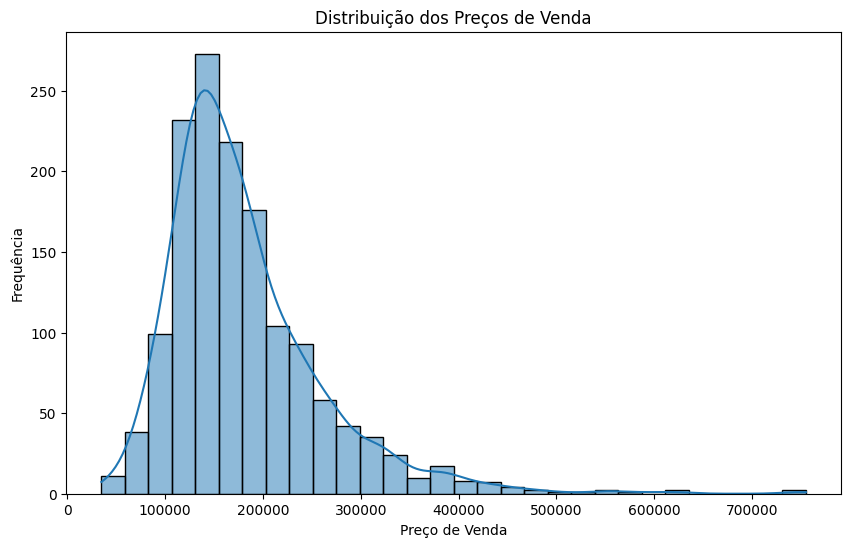

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma do preço de venda
plt.figure(figsize=(10,6))
sns.histplot(train['SalePrice'], bins=30, kde=True)
plt.title("Distribuição dos Preços de Venda")
plt.xlabel("Preço de Venda")
plt.ylabel("Frequência")
plt.show()

# Estatísticas básicas do preço
print(train['SalePrice'].describe())


In [13]:
# Selecionar apenas colunas numéricas
num_train = train.select_dtypes(include=['int64','float64'])

# Matriz de correlação
corr = num_train.corr()

# Correlação com SalePrice
sale_corr = corr['SalePrice'].sort_values(ascending=False)
print(sale_corr.head(10))  # top 10 variáveis mais correlacionadas


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [14]:
# Gráficos de dispersão das variáveis mais correlacionadas
top_features = ['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

for i, feature in enumerate(top_features, 1):
    plt.subplot

<Figure size 1500x1000 with 0 Axes>

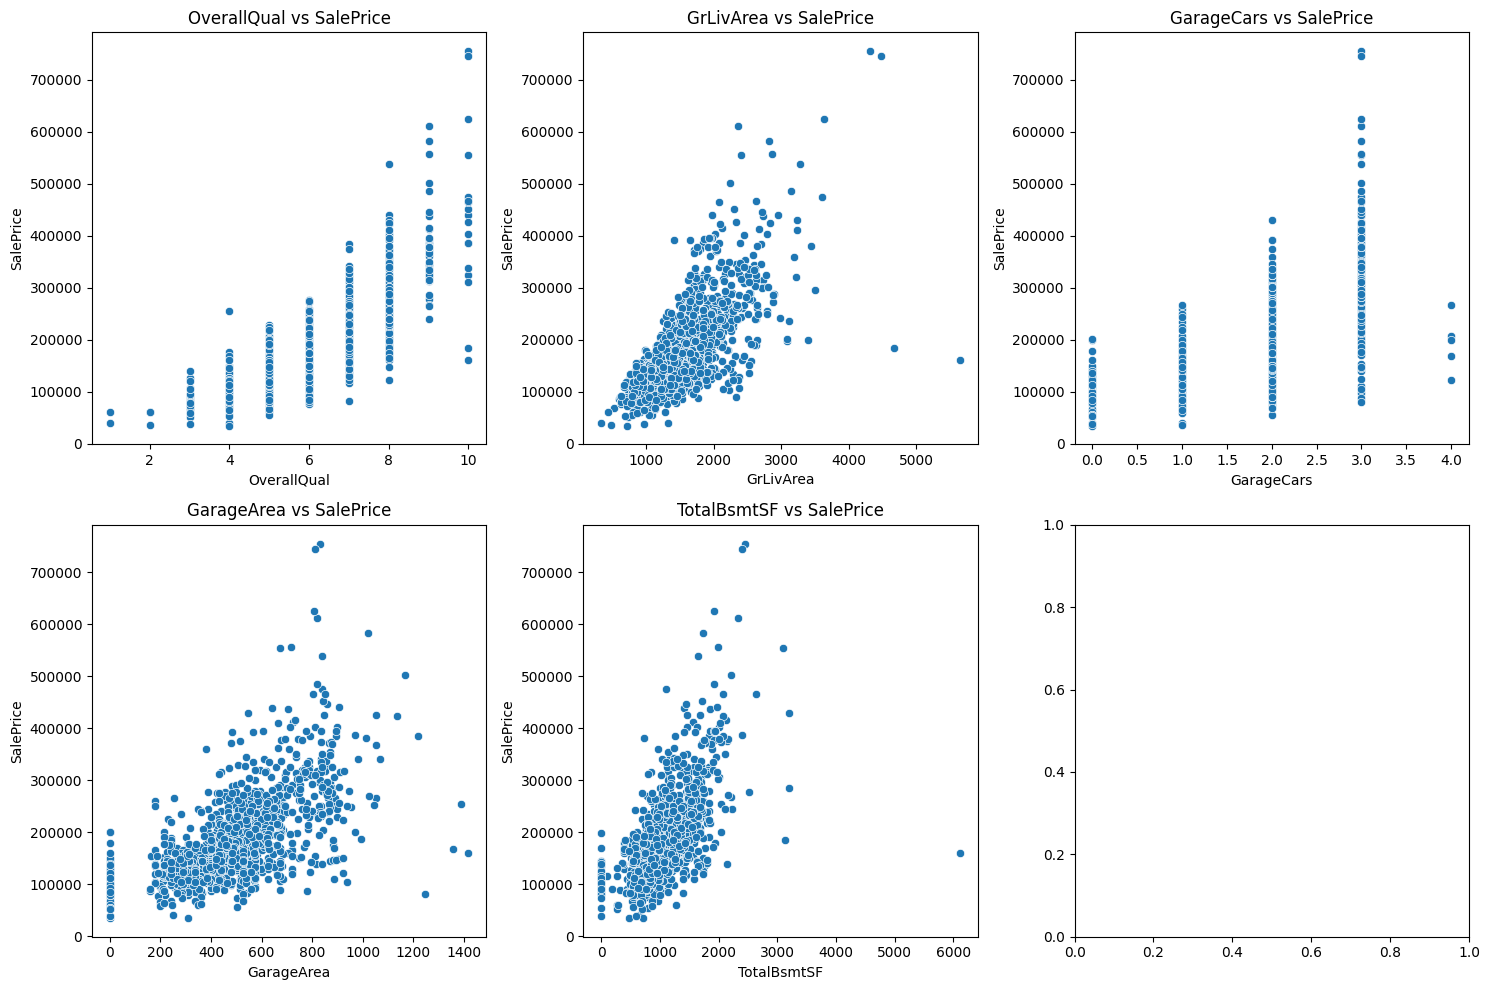

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variáveis mais correlacionadas
top_features = ['OverallQual','GrLivArea','GarageCars','GarageArea','TotalBsmtSF']

# Criar gráficos de dispersão
fig, axes = plt.subplots(2, 3, figsize=(15,10))

for i, feature in enumerate(top_features):
    row = i // 3
    col = i % 3
    sns.scatterplot(x=train[feature], y=train['SalePrice'], ax=axes[row, col])
    axes[row, col].set_title(f"{feature} vs SalePrice")

plt.tight_layout()
plt.show()


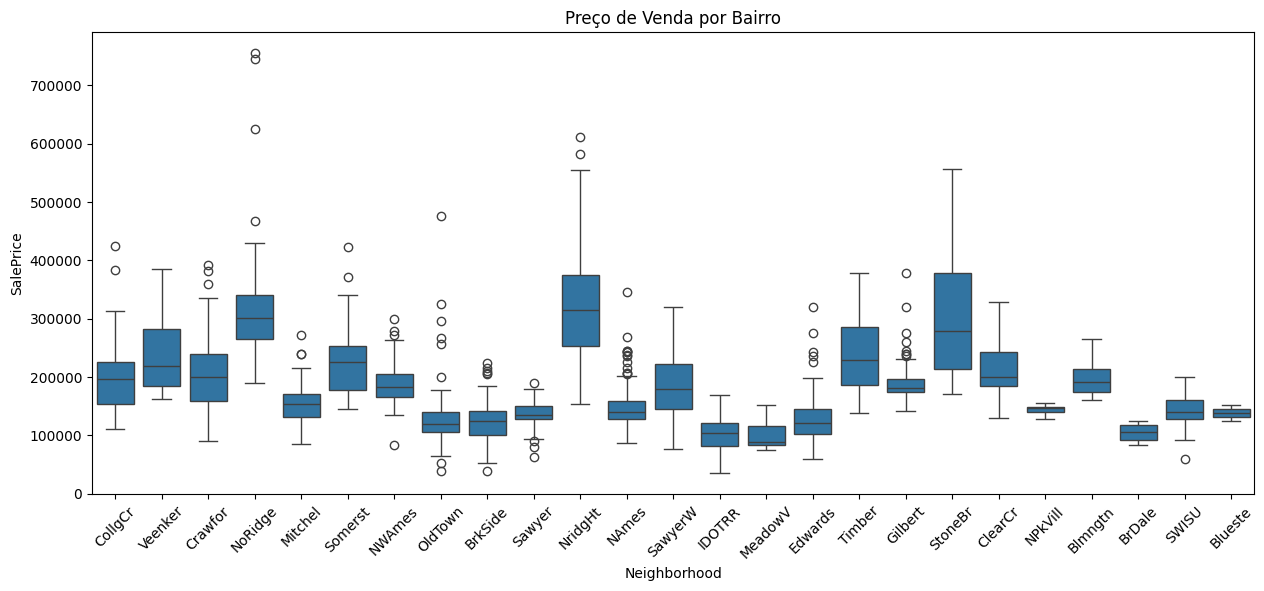

In [16]:
plt.figure(figsize=(15,6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=train)
plt.xticks(rotation=45)
plt.title("Preço de Venda por Bairro")
plt.show()


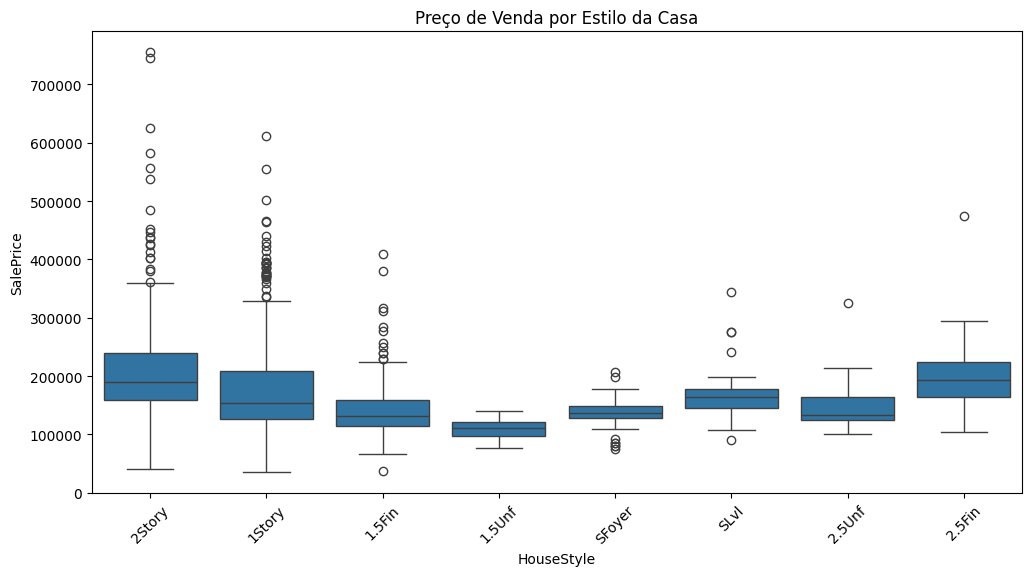

In [17]:
plt.figure(figsize=(12,6))
sns.boxplot(x="HouseStyle", y="SalePrice", data=train)
plt.xticks(rotation=45)
plt.title("Preço de Venda por Estilo da Casa")
plt.show()


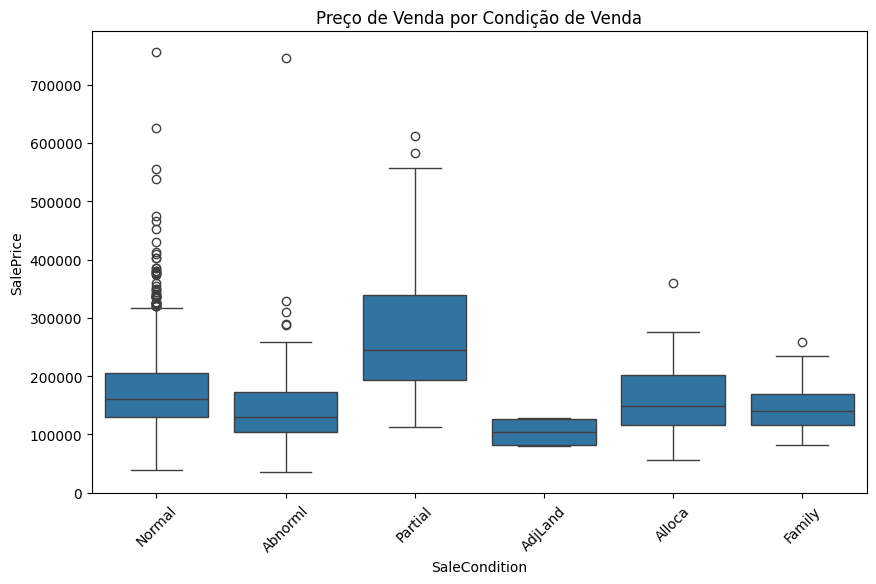

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x="SaleCondition", y="SalePrice", data=train)
plt.xticks(rotation=45)
plt.title("Preço de Venda por Condição de Venda")
plt.show()


In [19]:
# Contagem de valores nulos por coluna
missing = train.isnull().sum().sort_values(ascending=False)

# Mostrar as 15 colunas com mais nulos
print(missing.head(15))


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
dtype: int64


In [20]:
# Remover colunas com muitos nulos
train = train.drop(['PoolQC','MiscFeature','Alley','Fence'], axis=1)
test = test.drop(['PoolQC','MiscFeature','Alley','Fence'], axis=1)

print("Dimensões após remoção:", train.shape)


Dimensões após remoção: (1460, 77)


In [21]:
# Preencher categóricas com "None"
cat_fill = ['MasVnrType','FireplaceQu','GarageType','GarageFinish',
            'GarageQual','GarageCond','BsmtFinType2','BsmtExposure','BsmtCond']
for col in cat_fill:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

# Preencher numéricas com 0
num_fill_zero = ['GarageYrBlt','LotFrontage','MasVnrArea']
for col in num_fill_zero:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# Conferir se ainda restam nulos
print("Valores nulos restantes no treino:", train.isnull().sum().sum())
print("Valores nulos restantes no teste:", test.isnull().sum().sum())


Valores nulos restantes no treino: 75
Valores nulos restantes no teste: 108


In [22]:
# Aplicar one-hot encoding nas variáveis categóricas
train_encoded = pd.get_dummies(train, drop_first=True)
test_encoded = pd.get_dummies(test, drop_first=True)

# Alinhar colunas entre treino e teste (algumas categorias podem existir só em um dos conjuntos)
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

print("Dimensões do treino codificado:", train_encoded.shape)
print("Dimensões do teste codificado:", test_encoded.shape)


Dimensões do treino codificado: (1460, 246)
Dimensões do teste codificado: (1459, 246)


In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Separar variáveis preditoras e alvo
X = train_encoded.drop("SalePrice", axis=1)
y = train_encoded["SalePrice"]

# Dividir em treino e validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo de regressão linear
model = LinearRegression()
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_val)

# Avaliação
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print("RMSE:", rmse)
print("R²:", r2)


RMSE: 52382.45221707974
R²: 0.6422679784200602


In [24]:
from sklearn.ensemble import RandomForestRegressor

# Treinar Random Forest
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

# Previsões
y_pred_rf = rf_model.predict(X_val)

# Avaliação
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest - RMSE:", rmse_rf)
print("Random Forest - R²:", r2_rf)


Random Forest - RMSE: 29051.39132720441
Random Forest - R²: 0.889967738626872


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

print("Random Forest Ajustado - RMSE:", rmse_rf)
print("Random Forest Ajustado - R²:", r2_rf)


Random Forest Ajustado - RMSE: 29364.917968758928
Random Forest Ajustado - R²: 0.8875799563121626


In [26]:
# Previsões no conjunto de teste
test_predictions = rf_model.predict(test_encoded.drop("SalePrice", axis=1, errors="ignore"))

# Criar DataFrame de submissão
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": test_predictions
})

print(submission.head())


     Id      SalePrice
0  1461  128805.202823
1  1462  154390.239739
2  1463  178358.490737
3  1464  185347.134220
4  1465  205418.474209


In [27]:
# Salvar arquivo de submissão
submission.to_csv("submission.csv", index=False)


In [35]:
import os
print(os.getcwd())


/content


In [36]:
from google.colab import files

# Fazer upload do arquivo train.csv
uploaded = files.upload()


Saving train.csv to train.csv


In [37]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [38]:
# Criando novas colunas derivadas

# Idade da casa no ano da venda
df['AgeHouse'] = df['YrSold'] - df['YearBuilt']

# Área total construída (área acima do solo + porão)
df['TotalArea'] = df['GrLivArea'] + df['TotalBsmtSF']

# Conferir se funcionou
df[['YrSold','YearBuilt','AgeHouse','GrLivArea','TotalBsmtSF','TotalArea']].head()



,YrSold,YearBuilt,AgeHouse,GrLivArea,TotalBsmtSF,TotalArea
0,2008,2003,5,1710,856,2566
1,2007,1976,31,1262,1262,2524
2,2008,2001,7,1786,920,2706
3,2006,1915,91,1717,756,2473
4,2008,2000,8,2198,1145,3343


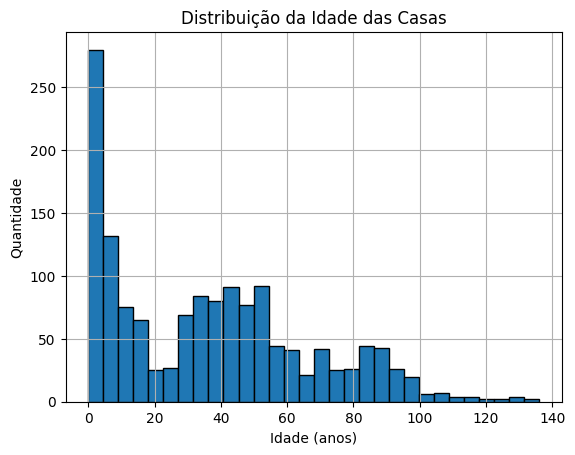

In [39]:
import matplotlib.pyplot as plt
df['AgeHouse'].hist(bins=30, edgecolor='black')
plt.title('Distribuição da Idade das Casas')
plt.xlabel('Idade (anos)')
plt.ylabel('Quantidade')
plt.show()


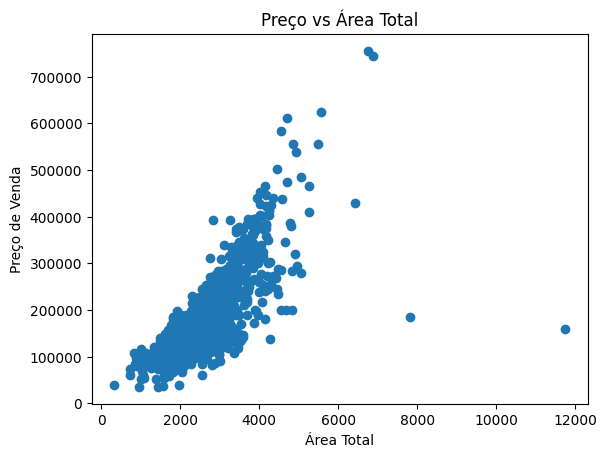

In [40]:
plt.scatter(df['TotalArea'], df['SalePrice'])
plt.title('Preço vs Área Total')
plt.xlabel('Área Total')
plt.ylabel('Preço de Venda')
plt.show()


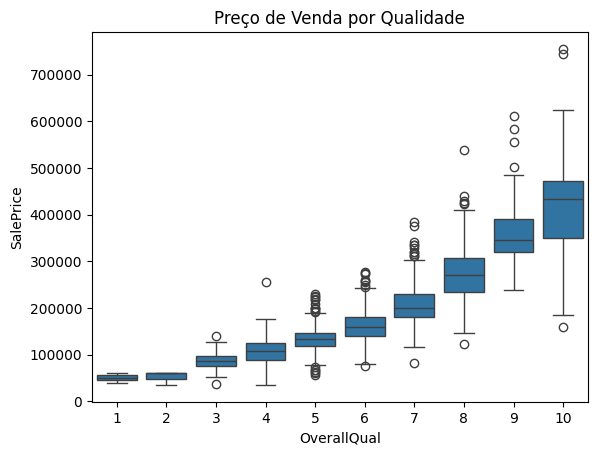

In [41]:
import seaborn as sns
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Preço de Venda por Qualidade')
plt.show()


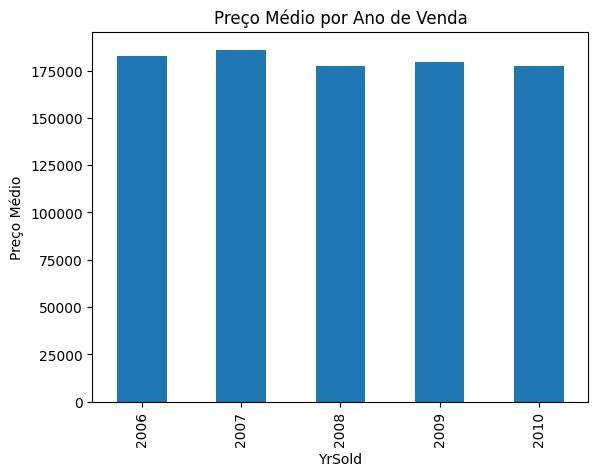

In [42]:
df.groupby('YrSold')['SalePrice'].mean().plot(kind='bar')
plt.title('Preço Médio por Ano de Venda')
plt.ylabel('Preço Médio')
plt.show()


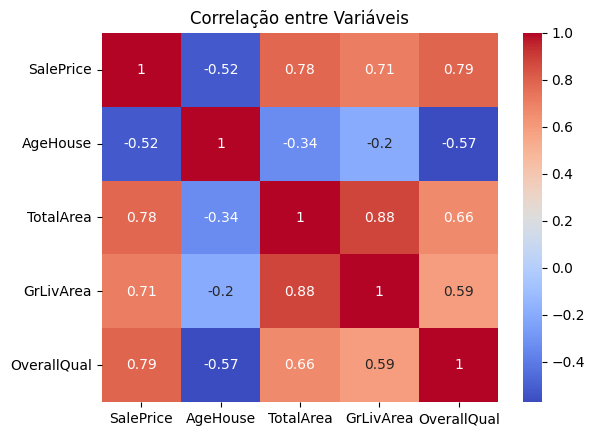

In [43]:
corr = df[['SalePrice','AgeHouse','TotalArea','GrLivArea','OverallQual']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlação entre Variáveis')
plt.show()


In [45]:
# Exportar o dataset tratado para CSV
df.to_csv('dataset_tratado.csv', index=False)


In [46]:
from google.colab import files
files.download('dataset_tratado.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Projeto Final EBAC – Previsão de Preços de Imóveis

Este projeto tem como objetivo prever o preço de venda de imóveis utilizando dados históricos da competição **House Prices: Advanced Regression Techniques (Kaggle)**.

---

## Pipeline de Ciência de Dados

O trabalho segue as etapas clássicas de um pipeline de ciência de dados:

1. Seleção dos Dados  
2. Análise Exploratória (EDA)  
3. Tratamento e Preparação dos Dados  
4. Modelagem  
5. Avaliação  
6. Previsões finais  
7. Visualização e Dashboard  

---

## Seleção dos Dados

Utilizamos a base pública *House Prices: Advanced Regression Techniques* do Kaggle.  
Ela contém três arquivos principais: `train.csv`, `test.csv` e `sample_submission.csv`.  

A base atende aos requisitos mínimos do projeto:
- Mais de 100 linhas.  
- Múltiplas colunas (81 variáveis).  
- Variáveis de data (`YrSold`).  
- Possibilidade de cruzamento entre tabelas (`train`, `test`, `sample_submission`).  

---

## Análise Exploratória (EDA)

- Avaliamos variáveis numéricas e categóricas.  
- Identificamos correlações importantes: `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`.  
- Observamos que bairros como **NridgHt** e **StoneBr** possuem preços mais altos.  
- Confirmamos que casas de dois andares tendem a ter preços maiores.  

---

## Tratamento e Preparação dos Dados

- Removemos colunas com muitos valores nulos: `PoolQC`, `MiscFeature`, `Alley`, `Fence`.  
- Preenchemos valores faltantes:  
  - Categóricas → `"None"`  
  - Numéricas → `0` ou mediana  
- Aplicamos **One-Hot Encoding** para transformar variáveis categóricas em numéricas.  
- Resultado: dataset final com **246 variáveis**.  

### Novas Colunas Derivadas
Criamos duas variáveis adicionais para enriquecer a análise:
- **AgeHouse**: diferença entre `YrSold` e `YearBuilt`, representando a idade da casa no momento da venda.  
- **TotalArea**: soma de `GrLivArea` e `TotalBsmtSF`, representando a área total construída.  

---

## Modelagem

### Regressão Linear (baseline)
- RMSE ≈ **52.382**  
- R² ≈ **0.64**

### Random Forest (modelo final)
- RMSE ≈ **29.051**  
- R² ≈ **0.89**

O **Random Forest** apresentou desempenho muito superior, reduzindo o erro em quase 50%.  

---

## Previsões Finais

- Geramos as previsões para o conjunto de teste.  
- Estruturamos o DataFrame final com `Id` e `SalePrice`.  
- Esse formato é compatível com submissão no Kaggle.  

---

## Visualizações

Foram gerados 5 gráficos principais para comunicar os insights:

1. **Histograma da idade das casas (`AgeHouse`)**  
2. **Dispersão entre área total (`TotalArea`) e preço de venda (`SalePrice`)**  
3. **Boxplot do preço por qualidade (`OverallQual`)**  
4. **Gráfico de barras do preço médio por ano de venda (`YrSold`)**  
5. **Mapa de calor de correlação entre variáveis relevantes**  

---

## Dashboard Interativo

Exportamos o dataset tratado para CSV e criamos um **dashboard no Looker Studio**.  
O dashboard inclui visualizações interativas que permitem explorar os principais insights da análise, como:  
- Preço médio por ano de venda.  
- Distribuição da idade das casas.  
- Correlação entre área total e preço.  
- Comparação de preços por qualidade.  
- Análise de bairros com maior valorização.  

---

## Conclusão

- Variáveis como **qualidade, área construída, garagem e bairro** são determinantes no preço dos imóveis.  
- O **Random Forest** se destacou como modelo mais eficiente.  


